In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm

In [2]:
TRAIN_START = "2020-01-01"
TRAIN_END = "2025-06-30"

In [80]:
# Remove SHIB-USD since it has inf value
ticker_universe = ["BTC-USD", "ETH-USD", "BNB-USD", "XRP-USD", "SOL-USD", "TRX-USD", "ZEC-USD", "DOGE-USD", "XMR-USD", "LINK-USD", "ADA-USD", "XLM-USD", "BCH-USD", "LTC-USD", "NEAR-USD", "AVAX-USD", "HBAR-USD", "KCS-USD", "ALGO-USD", "DASH-USD"]

In [81]:
daily_prices = yf.download(tickers=ticker_universe, period="max", interval="1d")

[*********************100%***********************]  20 of 20 completed


In [82]:
daily_returns = (daily_prices["Close"] / daily_prices["Close"].shift() - 1).loc[TRAIN_START:TRAIN_END]
daily_volumes = daily_prices["Volume"].loc[TRAIN_START:TRAIN_END]

In [166]:
def featureX():
    return pd.DataFrame({
        f"{x:02}LAG": daily_returns.shift(x).unstack(level=0)  for x in range(1, 60)
    } | {
        f"{x:02}AVG": daily_returns.shift().rolling(x).mean().unstack(level=0) for x in [7, 14, 28, 45, 60, 120]
    } | {
        f"{x:02}STD": daily_returns.shift().rolling(x).std().unstack(level=0) for x in [7, 14, 28, 45, 60, 120]
    }).dropna()

featureX()

01LAG     02LAG     03LAG     04LAG     05LAG  \
Ticker  Date                                                           
ADA-USD 2020-04-30  0.095349  0.012746  0.015737  0.081848  0.012898   
        2020-05-01 -0.074456  0.095349  0.012746  0.015737  0.081848   
        2020-05-02  0.071354 -0.074456  0.095349  0.012746  0.015737   
        2020-05-03 -0.004799  0.071354 -0.074456  0.095349  0.012746   
        2020-05-04 -0.040871 -0.004799  0.071354 -0.074456  0.095349   
...                      ...       ...       ...       ...       ...   
ZEC-USD 2025-06-26 -0.030015  0.025889  0.092435 -0.033046 -0.019128   
        2025-06-27 -0.056314 -0.030015  0.025889  0.092435 -0.033046   
        2025-06-28 -0.010150 -0.056314 -0.030015  0.025889  0.092435   
        2025-06-29  0.008083 -0.010150 -0.056314 -0.030015  0.025889   
        2025-06-30  0.028361  0.008083 -0.010150 -0.056314 -0.030015   

                       06LAG     07LAG     08LAG     09LAG     10LAG  ...  \
Ticker  Date                                                          ...   
ADA-USD 2020-04-30  0.031105  0.110670  0.053574  0.015303 -0.045762  ...   
        2020-05-01  0.012898  0.031105  0.110670  0.053574  0.015303  ...   
        2020-05-02  0.081848  0.012898  0.031105  0.110670  0.053574  ...   
        2020-05-03  0.015737  0.081848  0.012898  0.031105  0.110670  ...   
        2020-05-04  0.012746  0.015737  0.081848  0.012898  0.031105  ...   
...                      ...       ...       ...       ...       ...  ...   
ZEC-USD 2025-06-26 -0.036739 -0.007984  0.020974 -0.070762  0.021805  ...   
        2025-06-27 -0.019128 -0.036739 -0.007984  0.020974 -0.070762  ...   
        2025-06-28 -0.033046 -0.019128 -0.036739 -0.007984  0.020974  ...   
        2025-06-29  0.092435 -0.033046 -0.019128 -0.036739 -0.007984  ...   
        2025-06-30  0.025889  0.092435 -0.033046 -0.019128 -0.036739  ...   

                       28AVG     45AVG     60AVG    120AVG     07STD  \
Ticker  Date                                                           
ADA-USD 2020-04-30  0.019618  0.015931  0.004963  0.006097  0.042879   
        2020-05-01  0.015652  0.016734  0.004286  0.005321  0.055515   
        2020-05-02  0.017853  0.017286  0.004379  0.006092  0.058265   
        2020-05-03  0.017450  0.017098  0.004365  0.005688  0.059541   
        2020-05-04  0.016542  0.011703  0.003600  0.005246  0.059196   
...                      ...       ...       ...       ...       ...   
ZEC-USD 2025-06-26 -0.008121 -0.000815  0.004583  0.002779  0.046505   
        2025-06-27 -0.010259 -0.001775  0.003929  0.001685  0.051042   
        2025-06-28 -0.007250 -0.001534  0.002394  0.001452  0.049525   
        2025-06-29 -0.008419 -0.000745  0.003006  0.001319  0.049237   
        2025-06-30 -0.009058 -0.000070  0.002819  0.001503  0.047913   

                       14STD     28STD     45STD     60STD    120STD  
Ticker  Date                                                          
ADA-USD 2020-04-30  0.045265  0.046523  0.056147  0.079828  0.064961  
        2020-05-01  0.052064  0.049650  0.054531  0.080333  0.065365  
        2020-05-02  0.053099  0.050732  0.054964  0.080409  0.065595  
        2020-05-03  0.053222  0.050870  0.055026  0.080411  0.065511  
        2020-05-04  0.054848  0.051700  0.047942  0.080622  0.065646  
...                      ...       ...       ...       ...       ...  
ZEC-USD 2025-06-26  0.041433  0.043893  0.048372  0.045702  0.045291  
        2025-06-27  0.042581  0.044754  0.049045  0.046294  0.045117  
        2025-06-28  0.040850  0.041610  0.048975  0.045177  0.045105  
        2025-06-29  0.040919  0.040658  0.048834  0.044998  0.045061  
        2025-06-30  0.041821  0.039901  0.049026  0.044866  0.045127  

[37105 rows x 71 columns]

In [167]:
def Regression():
    N = 14
    X = featureX()
    # X = pd.DataFrame({
    #     1: (daily_returns.shift().rolling(14).mean() / daily_returns.shift().rolling(45).std()).unstack(level=0)
    # }).dropna()
    Y = (daily_returns.unstack(level=0) + daily_returns.shift(-1).unstack(level=0)).dropna()
    common_index = X.index.intersection(Y.index)
    model = sm.OLS(Y.loc[common_index], X.loc[common_index]).fit()
    return model

regression_model = Regression()

In [179]:
regression_model.f_pvalue

np.float64(1.8110381293666459e-121)

In [168]:
regression_model.pvalues.sort_values()[regression_model.pvalues < 0.05]

26LAG     1.552712e-12
120STD    1.156290e-11
09LAG     2.157138e-11
03LAG     6.078625e-11
24LAG     1.289852e-08
25LAG     2.211604e-08
27LAG     3.918451e-08
02LAG     4.533511e-08
58LAG     1.386381e-06
06LAG     8.292468e-06
10LAG     2.488763e-05
30LAG     3.143613e-05
60STD     8.841815e-05
42LAG     9.249338e-05
28AVG     1.011484e-04
14AVG     2.144476e-04
33LAG     3.299919e-04
19LAG     6.006378e-04
29LAG     6.264549e-04
07AVG     8.471714e-04
43LAG     9.265044e-04
59LAG     9.368135e-04
20LAG     1.030622e-03
57LAG     1.172294e-03
47LAG     1.416416e-03
34LAG     1.583810e-03
45AVG     1.731616e-03
55LAG     1.795569e-03
14STD     2.352953e-03
28LAG     3.408354e-03
48LAG     7.315552e-03
49LAG     7.466400e-03
28STD     9.209242e-03
56LAG     9.558097e-03
46LAG     1.202807e-02
54LAG     1.662904e-02
13LAG     2.219579e-02
14LAG     3.708195e-02
15LAG     3.923208e-02
60AVG     4.053223e-02
dtype: float64

In [169]:
def generateSignal(ticker="BTC-USD"):
    N = 14
    return (pd.DataFrame({
            f"{x:02}LAG": daily_returns[ticker].shift(x)  for x in range(1, 60)
        } | {
            f"{x:02}AVG": daily_returns[ticker].shift().rolling(x).mean() for x in [7, 14, 28, 45, 60, 120]
        } | {
            f"{x:02}STD": daily_returns[ticker].shift().rolling(x).std() for x in [7, 14, 28, 45, 60, 120]
    }) * regression_model.params).sum(axis=1)

In [170]:
def momentumWeights():
    signal = pd.DataFrame({ticker: generateSignal(ticker) for ticker in ticker_universe})
    ranked = signal.rank(axis=1)
    demeaned =  ranked.sub(ranked.mean(axis=1), axis=0)
    weights = demeaned.div(demeaned.abs().sum(axis=1), axis=0)
    lagged_weights = weights.iloc[::2].reindex(weights.index, method="ffill")
    return lagged_weights

momentumWeights()

,BTC-USD,ETH-USD,BNB-USD,XRP-USD,SOL-USD,TRX-USD,ZEC-USD,DOGE-USD,XMR-USD,LINK-USD,ADA-USD,XLM-USD,BCH-USD,LTC-USD,NEAR-USD,AVAX-USD,HBAR-USD,KCS-USD,ALGO-USD,DASH-USD
Date,,,,,,,,,,,,,,,,,,,,
2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,-0.025,0.015,-0.035,-0.055,-0.085,-0.065,0.035,-0.045,0.075,0.085,0.045,0.005,-0.015,0.065,-0.085,-0.085,0.095,-0.005,0.025,0.055
2020-01-04,-0.025,0.015,-0.035,-0.055,-0.085,-0.065,0.035,-0.045,0.075,0.085,0.045,0.005,-0.015,0.065,-0.085,-0.085,0.095,-0.005,0.025,0.055
2020-01-05,0.025,0.045,-0.075,-0.045,-0.025,0.015,0.005,0.075,0.095,-0.065,0.035,-0.085,0.085,-0.055,-0.025,-0.025,-0.095,-0.005,0.055,0.065
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-26,-0.035,0.065,-0.085,0.075,0.055,-0.075,0.035,-0.095,-0.045,0.045,0.085,-0.065,0.095,-0.015,-0.055,0.015,0.005,-0.005,-0.025,0.025
2025-06-27,0.035,0.055,0.015,0.095,-0.005,0.045,0.085,-0.035,-0.065,-0.055,0.075,0.005,-0.025,-0.015,-0.045,-0.085,0.025,0.065,-0.095,-0.075
2025-06-28,0.035,0.055,0.015,0.095,-0.005,0.045,0.085,-0.035,-0.065,-0.055,0.075,0.005,-0.025,-0.015,-0.045,-0.085,0.025,0.065,-0.095,-0.075


In [171]:
def grossMomentum():
    return (momentumWeights() * daily_returns).sum(axis=1)

grossMomentum().sort_values()

Date
2024-12-03   -0.080100
2024-11-23   -0.066641
2021-01-30   -0.058162
2020-07-16   -0.045308
2020-03-18   -0.041135
                ...   
2021-04-13    0.074284
2021-04-16    0.093668
2020-03-12    0.096645
2020-02-12    0.107590
2021-01-28    0.274685
Length: 2008, dtype: float64

In [172]:
def sharpeRatio(x):
    return x.mean() / x.std() * np.sqrt(252)

In [173]:
f"Sharpe Ratio: {sharpeRatio(grossMomentum()):.2f}"

'Sharpe Ratio: 1.36'

In [174]:
def turnOver(weights):
    return (weights - weights.shift()).abs().sum(axis=1)

def netMomentum():
    gross_momentum = grossMomentum()
    turnover = turnOver(momentumWeights())
    net_momentum = gross_momentum.subtract(turnover * 0.002, fill_value=0)
    return net_momentum

netMomentum().describe()

count    2008.000000
mean        0.000011
std         0.014082
min        -0.082740
25%        -0.006393
50%        -0.000730
75%         0.005435
max         0.274685
dtype: float64

In [175]:
sharpeRatio(netMomentum())

np.float64(0.012435759170847849)

C:\Users\jibri\AppData\Local\Temp\ipykernel_21788\3471066728.py:1: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  grossMomentum().resample("Q").apply(sharpeRatio).to_period("Q").plot(kind="bar")
C:\Users\jibri\AppData\Local\Temp\ipykernel_21788\3471066728.py:2: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  netMomentum().resample("Q").apply(sharpeRatio).to_period("Q").plot(kind="bar")


<Axes: xlabel='Date'>

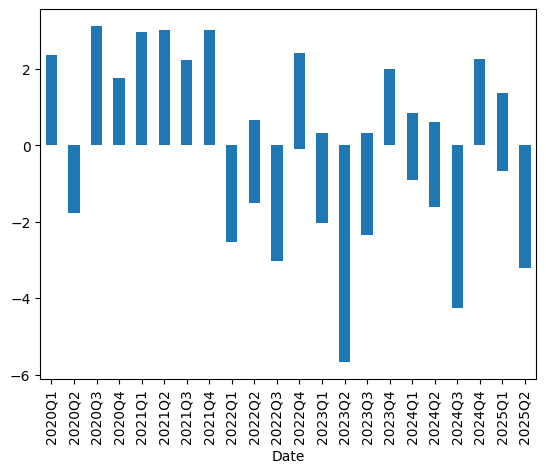

In [ ]:
grossMomentum().resample("QE").apply(sharpeRatio).to_period("Q").plot(kind="bar")

<Axes: xlabel='Date'>

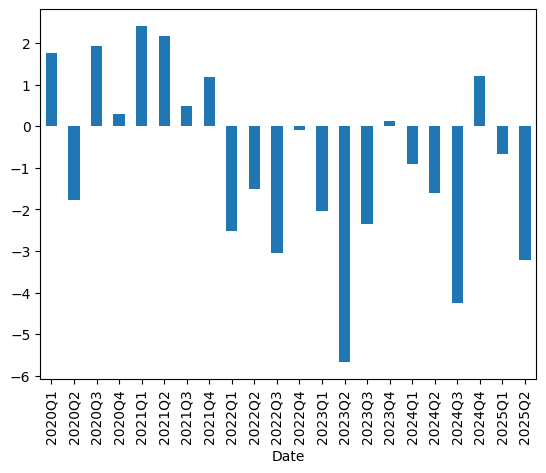

In [178]:
netMomentum().resample("QE").apply(sharpeRatio).to_period("Q").plot(kind="bar")